# Problem 1 Notebook (SetpLR and float64 for 22.5k)

## Imports

In [1]:
import json
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import scipy

## Configuration

In [2]:
# Toggle a short run before committing to a long training job.
TEST_RUN = False
TEST_EPOCHS = 1000
FULL_EPOCHS = 22500
ITERATIONS = TEST_EPOCHS if TEST_RUN else FULL_EPOCHS
FORCE_DEVICE = False
USE_DATA_PART_E = False
RANDOM_SEED = 1234

# Run tracking and checkpointing.
RUN_NAME = None  # Set explicitly when resuming or when you want a stable run folder.
RESUME_TRAINING = False
SAVE_CHECKPOINTS = True
TRACK_EXPERIMENTS = True
CHECKPOINT_EVERY = max(1, TEST_EPOCHS // 5) if TEST_RUN else 500

DATA_PATH = 'plate_data.mat'
MEASUREMENT_POINT_COUNT = 50

DISP_LAYERS = [2, 300, 300, 2]
STRESS_LAYERS = [2, 400, 400, 3]
ACTIVATION = nn.Tanh

YOUNGS_MODULUS = 10.0
POISSON_RATIO = 0.3
RIGHT_TRACTION = 0.1
TOP_TRACTION = 0.0

LOSS_FUNCTION = nn.MSELoss()
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 10000
LR_GAMMA = 0.5
DATA_LOSS_WEIGHT = 100.0
PRINT_EVERY = max(1, TEST_EPOCHS // 100) if TEST_RUN else 100
SAVE_FIGURES = True
FIGURE_DPI = 300

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

run_mode = 'test' if TEST_RUN else 'full'
if RESUME_TRAINING and RUN_NAME is None:
    raise ValueError('Set RUN_NAME to an existing run folder when RESUME_TRAINING=True.')
if RUN_NAME is None:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    data_tag = 'data' if USE_DATA_PART_E else 'nodata'
    RUN_NAME = f'problem1_{timestamp}_{run_mode}_{data_tag}_seed{RANDOM_SEED}'

EXPERIMENT_ROOT = Path('problem_1_experiments')
RUN_DIR = EXPERIMENT_ROOT / RUN_NAME
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
TRACKING_DIR = RUN_DIR / 'tracking'
FIGURE_DIR = Path('problem_1_figures') / RUN_NAME
for directory in [EXPERIMENT_ROOT, RUN_DIR, CHECKPOINT_DIR, TRACKING_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LATEST_CHECKPOINT_PATH = CHECKPOINT_DIR / 'latest.pt'
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / 'best.pt'
RUN_TRACKING_PATH = TRACKING_DIR / 'run_tracking.json'
LOSS_HISTORY_PATH = TRACKING_DIR / 'loss_history.npz'
SUMMARY_LOG_PATH = EXPERIMENT_ROOT / 'experiment_summary.jsonl'

def to_serializable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, torch.dtype):
        return str(value)
    if isinstance(value, torch.device):
        return str(value)
    if isinstance(value, type):
        return value.__name__
    if isinstance(value, (list, tuple)):
        return [to_serializable(v) for v in value]
    if isinstance(value, dict):
        return {k: to_serializable(v) for k, v in value.items()}
    if isinstance(value, np.generic):
        return value.item()
    return value

def save_current_figure(filename):
    if SAVE_FIGURES:
        output_path = FIGURE_DIR / filename
        plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f'Saved figure to {output_path}')

print(f'Configured {run_mode} run for {ITERATIONS} epochs')
print(f'RUN_NAME={RUN_NAME}')
print(f'USE_DATA_PART_E={USE_DATA_PART_E}, RANDOM_SEED={RANDOM_SEED}')

Configured full run for 22500 epochs
RUN_NAME=problem1_20260313_233004_full_nodata_seed1234
USE_DATA_PART_E=False, RANDOM_SEED=1234


## Device setting and speed check

In [3]:
# Pick the fastest available device, then test whether it can run float64.
if torch.backends.mps.is_available():
    requested_device = torch.device("mps")
    print("Selected Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    requested_device = torch.device("cuda")
    print("Selected NVIDIA GPU (CUDA)")
else:
    requested_device = torch.device("cpu")
    print("Selected CPU")

try:
    test_tensor = torch.ones((100, 100), dtype=torch.float64, device=requested_device)
    _ = test_tensor @ test_tensor
    device = requested_device
    FLOAT_BITS = torch.float64
    print(f"Float64 is supported on {device}.")
except Exception as e:
    if FORCE_DEVICE and requested_device.type != "cpu":
        device = requested_device
        FLOAT_BITS = torch.float32
        print(f"Float64 is not supported on {device}; forcing device usage with float32.")
    else:
        device = torch.device("cpu")
        FLOAT_BITS = torch.float64
        print("Float64 is not supported on the selected accelerator; falling back to CPU float64.")
    print(f"Error details: {e}")

torch.set_default_dtype(FLOAT_BITS)
print(f"Final configuration: device={device}, dtype={FLOAT_BITS}, FORCE_DEVICE={FORCE_DEVICE}")

Selected Apple Silicon GPU (MPS)
Float64 is not supported on the selected accelerator; falling back to CPU float64.
Error details: Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64. Please use float32 instead.
Final configuration: device=cpu, dtype=torch.float64, FORCE_DEVICE=False


## Define Neural Network

In [4]:

# Define Neural Network
class DenseNet(nn.Module):
    def __init__(self, layers, nonlinearity):
        super(DenseNet, self).__init__()

        self.n_layers = len(layers) - 1

        assert self.n_layers >= 1

        self.layers = nn.ModuleList()

        for j in range(self.n_layers):
            self.layers.append(nn.Linear(layers[j], layers[j + 1]))

            if j != self.n_layers - 1:
                self.layers.append(nonlinearity())

    def forward(self, x):
        for _, l in enumerate(self.layers):
            x = l(x)

        return x

## Data Processing

In [5]:

############################# Data processing #############################
# Read data from mat
# Specify your data path here
path = DATA_PATH
data = scipy.io.loadmat(path)
L_boundary = torch.tensor(data['L_boundary'], dtype=FLOAT_BITS, device=device)
R_boundary = torch.tensor(data['R_boundary'], dtype=FLOAT_BITS, device=device)
T_boundary = torch.tensor(data['T_boundary'], dtype=FLOAT_BITS, device=device)
B_boundary = torch.tensor(data['B_boundary'], dtype=FLOAT_BITS, device=device)
C_boundary = torch.tensor(data['C_boundary'], dtype=FLOAT_BITS, device=device)
Boundary   = torch.tensor(data['Boundary'], dtype=FLOAT_BITS, device=device, requires_grad=True)

# truth solution from FEM
disp_truth = torch.tensor(data['disp_data'], dtype=FLOAT_BITS, device=device)

# connectivity matrix - this helps you to plot the figure but we do not need it for PINN
t_connect  = torch.tensor(data['t'].astype(float), dtype=FLOAT_BITS, device=device)

# all collocation points
x_full = torch.tensor(data['p_full'], dtype=FLOAT_BITS, device=device, requires_grad=True)

# collocation points excluding the boundary
x = torch.tensor(data['p'], dtype=FLOAT_BITS, device=device, requires_grad=True)

# This chooses 50 fixed points from the truth solution, which we will use for part (e)
rand_index = torch.randint(0, len(x_full), (MEASUREMENT_POINT_COUNT,), device=device)
x_fix = x_full[rand_index, :]
disp_fix = disp_truth[rand_index,:]




## Network architecture and protocols

In [6]:
# We will use two neural networks for the problem:
# NN1: to map the coordinates [x,y] to displacement u
# NN2: to map the coordinates [x,y] to the stresses [sigma_11, sigma_22, sigma_12]
# What we will do later is to first compute strain by differentiate the output of NN1
# And then we compute a augment stress using Hook's law to find an augmented stress sigma_a
# And we will require the output of NN2 to match sigma_a  - we shall do this by adding a term in the loss function
# This will help us to avoid differentiating NN1 twice (why?)
# As it is well known that PINN suffers from higher order derivatives

Disp_layer = DISP_LAYERS # Architecture of displacement net - you may change as you wish
Stress_layer = STRESS_LAYERS # Architecture of stress net - you may change as you wish

stress_net = DenseNet(Stress_layer, ACTIVATION).to(device=device, dtype=FLOAT_BITS) # Note we choose hyperbolic tangent as an activation function here
disp_net =  DenseNet(Disp_layer, ACTIVATION).to(device=device, dtype=FLOAT_BITS)

# Define material properties
E = YOUNGS_MODULUS
mu = POISSON_RATIO

stiff = E/(1-mu**2)*torch.tensor([[1,mu,0],[mu,1,0],[0,0,(1-mu)/2]], dtype=FLOAT_BITS, device=device) # Hooke's law for plane stress
stiff = stiff.unsqueeze(0)

# PINN requires super large number of iterations to converge (on the order of 50e^3-100e^3)
#
iterations = ITERATIONS

# Define loss function
loss_func = LOSS_FUNCTION

# Broadcast stiffness for batch multiplication later
stiff_bc = stiff
stiff = torch.broadcast_to(stiff, (len(x),3,3))

stiff_bc = torch.broadcast_to(stiff_bc, (len(Boundary),3,3))

params = list(stress_net.parameters()) + list(disp_net.parameters())

# Define optimizer and scheduler
optimizer = torch.optim.Adam(params, lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)

def move_optimizer_state(optimizer, target_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(target_device)

def build_run_config():
    return {
        'run_name': RUN_NAME,
        'test_run': TEST_RUN,
        'test_epochs': TEST_EPOCHS,
        'full_epochs': FULL_EPOCHS,
        'iterations': iterations,
        'force_device': FORCE_DEVICE,
        'use_data_part_e': USE_DATA_PART_E,
        'random_seed': RANDOM_SEED,
        'data_path': DATA_PATH,
        'measurement_point_count': MEASUREMENT_POINT_COUNT,
        'disp_layers': DISP_LAYERS,
        'stress_layers': STRESS_LAYERS,
        'activation': ACTIVATION,
        'youngs_modulus': YOUNGS_MODULUS,
        'poisson_ratio': POISSON_RATIO,
        'right_traction': RIGHT_TRACTION,
        'top_traction': TOP_TRACTION,
        'learning_rate': LEARNING_RATE,
        'lr_step_size': LR_STEP_SIZE,
        'lr_gamma': LR_GAMMA,
        'data_loss_weight': DATA_LOSS_WEIGHT,
        'checkpoint_every': CHECKPOINT_EVERY,
        'device': device,
        'dtype': FLOAT_BITS,
        'resume_training': RESUME_TRAINING,
    }

def save_loss_history_npz(history):
    if TRACK_EXPERIMENTS:
        np.savez(LOSS_HISTORY_PATH, **{key: np.asarray(values) for key, values in history.items()})

def write_run_tracking(history, status, epoch, current_loss, best_loss):
    if not TRACK_EXPERIMENTS:
        return None
    best_epoch = int(np.argmin(history['total'])) if history['total'] else None
    record = {
        'run_name': RUN_NAME,
        'status': status,
        'epoch': int(epoch),
        'best_epoch': best_epoch,
        'current_loss': float(current_loss),
        'best_loss': float(best_loss),
        'final_learning_rate': float(history['lr'][-1]) if history['lr'] else LEARNING_RATE,
        'history_length': len(history['total']),
        'paths': {
            'run_dir': RUN_DIR,
            'checkpoint_dir': CHECKPOINT_DIR,
            'latest_checkpoint': LATEST_CHECKPOINT_PATH,
            'best_checkpoint': BEST_CHECKPOINT_PATH,
            'figure_dir': FIGURE_DIR,
            'loss_history': LOSS_HISTORY_PATH,
        },
        'config': build_run_config(),
    }
    with RUN_TRACKING_PATH.open('w', encoding='utf-8') as f:
        json.dump(to_serializable(record), f, indent=2)
    save_loss_history_npz(history)
    return record

def append_experiment_summary(record):
    if TRACK_EXPERIMENTS and record is not None:
        with SUMMARY_LOG_PATH.open('a', encoding='utf-8') as f:
            f.write(json.dumps(to_serializable(record)) + '\n')

def build_checkpoint(epoch, history, current_loss, best_loss):
    return {
        'epoch': int(epoch),
        'current_loss': float(current_loss),
        'best_loss': float(best_loss),
        'stress_net_state_dict': stress_net.state_dict(),
        'disp_net_state_dict': disp_net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss_history': history,
        'rand_index': rand_index.detach().cpu(),
        'config': to_serializable(build_run_config()),
    }

def save_checkpoint(epoch, history, current_loss, best_loss, save_latest=False, save_best=False):
    if not SAVE_CHECKPOINTS:
        return
    payload = build_checkpoint(epoch, history, current_loss, best_loss)
    if save_latest:
        torch.save(payload, LATEST_CHECKPOINT_PATH)
    if save_best:
        torch.save(payload, BEST_CHECKPOINT_PATH)

def load_model_weights_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    stress_net.load_state_dict(checkpoint['stress_net_state_dict'])
    disp_net.load_state_dict(checkpoint['disp_net_state_dict'])
    return checkpoint

start_epoch = 0
best_loss = float('inf')
resume_history = None
if RESUME_TRAINING:
    if not LATEST_CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f'Checkpoint not found: {LATEST_CHECKPOINT_PATH}')
    checkpoint = torch.load(LATEST_CHECKPOINT_PATH, map_location=device)
    stress_net.load_state_dict(checkpoint['stress_net_state_dict'])
    disp_net.load_state_dict(checkpoint['disp_net_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    move_optimizer_state(optimizer, device)
    best_loss = float(checkpoint.get('best_loss', float('inf')))
    start_epoch = int(checkpoint['epoch']) + 1
    resume_history = checkpoint.get('loss_history')
    if 'rand_index' in checkpoint:
        rand_index = checkpoint['rand_index'].to(device=device)
        x_fix = x_full[rand_index, :]
        disp_fix = disp_truth[rand_index, :]
    print(f'Resuming training from epoch {start_epoch} using {LATEST_CHECKPOINT_PATH}')
else:
    print(f'Starting fresh run in {RUN_DIR}')

Starting fresh run in problem_1_experiments/problem1_20260313_233004_full_nodata_seed1234


## Training

In [7]:

history_template = {
    'total': [],
    'eq_total': [],
    'eq_x1': [],
    'eq_x2': [],
    'cons': [],
    'cons_bc': [],
    'bc_total': [],
    'bc_L': [],
    'bc_B': [],
    'bc_R': [],
    'bc_T': [],
    'bc_C': [],
    'data': [],
    'lr': [],
}
loss_history = {key: [] for key in history_template}
if resume_history is not None:
    for key in history_template:
        loss_history[key] = list(resume_history.get(key, []))
    print(f"Loaded history with {len(loss_history['total'])} recorded epochs")

last_epoch = start_epoch - 1
if start_epoch >= iterations:
    print(f'Checkpoint already reached epoch {start_epoch}; nothing to train for ITERATIONS={iterations}.')

for epoch in range(start_epoch, iterations):
    optimizer.zero_grad()

    # To compute stress from stress net
    sigma = stress_net(x)
    # To compute displacement from disp net
    disp     = disp_net(x)

    # displacement in x direction
    u = disp[:,0]
    # displacement in y direction
    v = disp[:,1]

    # find the derivatives
    dudx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),create_graph=True)[0]
    dvdx = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v),create_graph=True)[0]

    # Define strain
    e_11 = dudx[:,0].unsqueeze(1)
    e_22 = dvdx[:,1].unsqueeze(1)
    e_12 = 0.5*(dudx[:,1] + dvdx[:,0]).unsqueeze(1)

    e = torch.cat((e_11,e_22,e_12), 1)
    e = e.unsqueeze(2)

    # Define augment stress
    sig_aug = torch.bmm(stiff, e).squeeze(2)

    # Define constitutive loss - forcing the augment stress to be equal to the neural network stress
    loss_cons = loss_func(sig_aug, sigma)

    # find displacement and stress at the boundaries
    disp_bc = disp_net(Boundary)
    sigma_bc = stress_net(Boundary)
    u_bc = disp_bc[:,0]
    v_bc = disp_bc[:,1]

    # Compute the strain and stresses at the boundary
    dudx_bc = torch.autograd.grad(u_bc, Boundary, grad_outputs=torch.ones_like(u_bc),create_graph=True)[0]
    dvdx_bc = torch.autograd.grad(v_bc, Boundary, grad_outputs=torch.ones_like(v_bc),create_graph=True)[0]

    e_11_bc = dudx_bc[:,0].unsqueeze(1)
    e_22_bc = dvdx_bc[:,1].unsqueeze(1)
    e_12_bc = 0.5*(dudx_bc[:,1] + dvdx_bc[:,0]).unsqueeze(1)

    e_bc = torch.cat((e_11_bc,e_22_bc,e_12_bc), 1)
    e_bc = e_bc.unsqueeze(2)

    sig_aug_bc = torch.bmm(stiff_bc, e_bc).squeeze(2)

    # force the augment stress to agree with the NN stress at the boundary
    loss_cons_bc = loss_func(sig_aug_bc, sigma_bc)

    #============= equilibrium ===================#

    sig_11 = sigma[:,0]
    sig_22 = sigma[:,1]
    sig_12 = sigma[:,2]

    # stress equilibrium in x and y direction
    dsig11dx = torch.autograd.grad(sig_11, x, grad_outputs=torch.ones_like(sig_11),create_graph=True)[0]
    dsig22dx = torch.autograd.grad(sig_22, x, grad_outputs=torch.ones_like(sig_22),create_graph=True)[0]
    dsig12dx = torch.autograd.grad(sig_12, x, grad_outputs=torch.ones_like(sig_12),create_graph=True)[0]

    eq_x1 = dsig11dx[:,0]+dsig12dx[:,1]
    eq_x2 = dsig12dx[:,0]+dsig22dx[:,1]

    # zero body forces
    f_x1 = torch.zeros_like(eq_x1)
    f_x2 = torch.zeros_like(eq_x2)

    loss_eq1 = loss_func(eq_x1, f_x1)
    loss_eq2 = loss_func(eq_x2, f_x2)
    #========= boundary ========================#

    # specify the boundary condition
    tau_R = RIGHT_TRACTION
    tau_T = TOP_TRACTION
    #
    u_L= disp_net(L_boundary)
    u_B = disp_net(B_boundary)

    sig_R = stress_net(R_boundary)
    sig_T = stress_net(T_boundary)
    sig_C = stress_net(C_boundary)

    # Symmetry boundary condition left
    loss_BC_L = loss_func(u_L[:,0], torch.zeros_like(u_L[:,0]))
    # Symmetry boundary condition bottom
    loss_BC_B = loss_func(u_B[:, 1], torch.zeros_like(u_B[:, 1]))
    # Force boundary condition right
    loss_BC_R = loss_func(sig_R[:, 0], tau_R*torch.ones_like(sig_R[:, 0])) \
                + loss_func(sig_R[:, 2],  torch.zeros_like(sig_R[:, 2]))

    loss_BC_T = + loss_func(sig_T[:, 1], tau_T*torch.ones_like(sig_T[:, 1]))   \
                + loss_func(sig_T[:, 2],  torch.zeros_like(sig_T[:, 2]))

    # traction free on circle
    loss_BC_C = loss_func(sig_C[:,0]*C_boundary[:,0]+sig_C[:,2]*C_boundary[:,1], torch.zeros_like(sig_C[:, 0]))  \
                + loss_func(sig_C[:,2]*C_boundary[:,0]+sig_C[:,1]*C_boundary[:,1], torch.zeros_like(sig_C[:, 0]))

    loss_eq = loss_eq1 + loss_eq2
    loss_bc = loss_BC_L + loss_BC_B + loss_BC_R + loss_BC_T + loss_BC_C
    loss_data = torch.zeros((), dtype=FLOAT_BITS, device=device)

    # Define loss function:
    loss = loss_eq + loss_cons + loss_bc + loss_cons_bc


    if USE_DATA_PART_E:
        u_fix = disp_net(x_fix)
        loss_data = loss_func(u_fix, disp_fix)
        loss = loss + DATA_LOSS_WEIGHT * loss_data


    current_loss = loss.detach().cpu().item()
    loss_history['total'].append(current_loss)
    loss_history['eq_total'].append(loss_eq.detach().cpu().item())
    loss_history['eq_x1'].append(loss_eq1.detach().cpu().item())
    loss_history['eq_x2'].append(loss_eq2.detach().cpu().item())
    loss_history['cons'].append(loss_cons.detach().cpu().item())
    loss_history['cons_bc'].append(loss_cons_bc.detach().cpu().item())
    loss_history['bc_total'].append(loss_bc.detach().cpu().item())
    loss_history['bc_L'].append(loss_BC_L.detach().cpu().item())
    loss_history['bc_B'].append(loss_BC_B.detach().cpu().item())
    loss_history['bc_R'].append(loss_BC_R.detach().cpu().item())
    loss_history['bc_T'].append(loss_BC_T.detach().cpu().item())
    loss_history['bc_C'].append(loss_BC_C.detach().cpu().item())
    loss_history['data'].append(loss_data.detach().cpu().item())
    loss_history['lr'].append(optimizer.param_groups[0]['lr'])

    is_best = current_loss < best_loss
    if is_best:
        best_loss = current_loss
        save_checkpoint(epoch, loss_history, current_loss, best_loss, save_best=True)

    loss.backward()
    if epoch % PRINT_EVERY == 0 or epoch == iterations - 1:
        print('loss', loss, 'iter', epoch)
    optimizer.step()
    scheduler.step()
    last_epoch = epoch

    should_checkpoint = (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch == iterations - 1
    if should_checkpoint:
        save_checkpoint(epoch, loss_history, current_loss, best_loss, save_latest=True)
    if should_checkpoint or is_best:
        status = 'completed' if epoch == iterations - 1 else 'running'
        write_run_tracking(loss_history, status=status, epoch=epoch, current_loss=current_loss, best_loss=best_loss)

final_loss = loss_history['total'][-1] if loss_history['total'] else float('inf')
final_status = 'completed' if (iterations > 0 and (last_epoch >= iterations - 1 or start_epoch >= iterations)) else 'not_started'
final_record = write_run_tracking(loss_history, status=final_status, epoch=last_epoch, current_loss=final_loss, best_loss=best_loss)
append_experiment_summary(final_record)

loss tensor(5.0135, grad_fn=<AddBackward0>) iter 0
loss tensor(0.0020, grad_fn=<AddBackward0>) iter 100
loss tensor(0.0007, grad_fn=<AddBackward0>) iter 200
loss tensor(0.0004, grad_fn=<AddBackward0>) iter 300
loss tensor(0.0003, grad_fn=<AddBackward0>) iter 400
loss tensor(0.0002, grad_fn=<AddBackward0>) iter 500
loss tensor(0.0002, grad_fn=<AddBackward0>) iter 600
loss tensor(0.0001, grad_fn=<AddBackward0>) iter 700
loss tensor(0.0001, grad_fn=<AddBackward0>) iter 800
loss tensor(0.0001, grad_fn=<AddBackward0>) iter 900
loss tensor(8.8831e-05, grad_fn=<AddBackward0>) iter 1000
loss tensor(7.8876e-05, grad_fn=<AddBackward0>) iter 1100
loss tensor(7.0761e-05, grad_fn=<AddBackward0>) iter 1200
loss tensor(6.4093e-05, grad_fn=<AddBackward0>) iter 1300
loss tensor(5.8571e-05, grad_fn=<AddBackward0>) iter 1400
loss tensor(0.0001, grad_fn=<AddBackward0>) iter 1500
loss tensor(5.0836e-05, grad_fn=<AddBackward0>) iter 1600
loss tensor(4.7365e-05, grad_fn=<AddBackward0>) iter 1700
loss tensor(

## Plot training loss

Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/training_loss.png


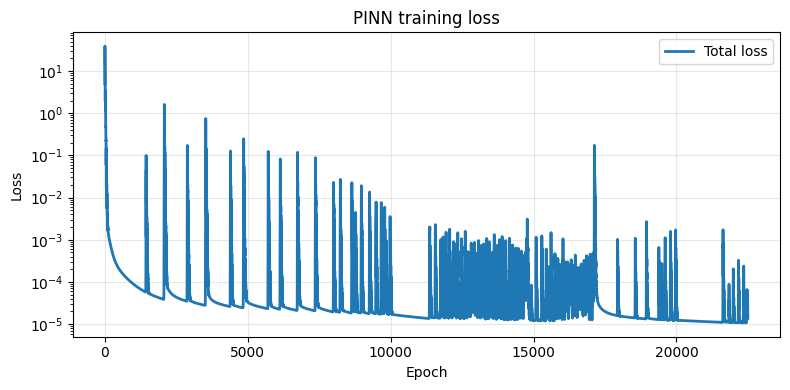

In [8]:
if not loss_history['total']:
    raise RuntimeError('Run the training cell before plotting losses.')

epochs = np.arange(1, len(loss_history['total']) + 1)
safe_total = np.maximum(np.asarray(loss_history['total']), 1e-16)

plt.figure(figsize=(8, 4))
plt.semilogy(epochs, safe_total, label='Total loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN training loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
save_current_figure('training_loss.png')
plt.show()

## Plot loss components

Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/loss_components.png


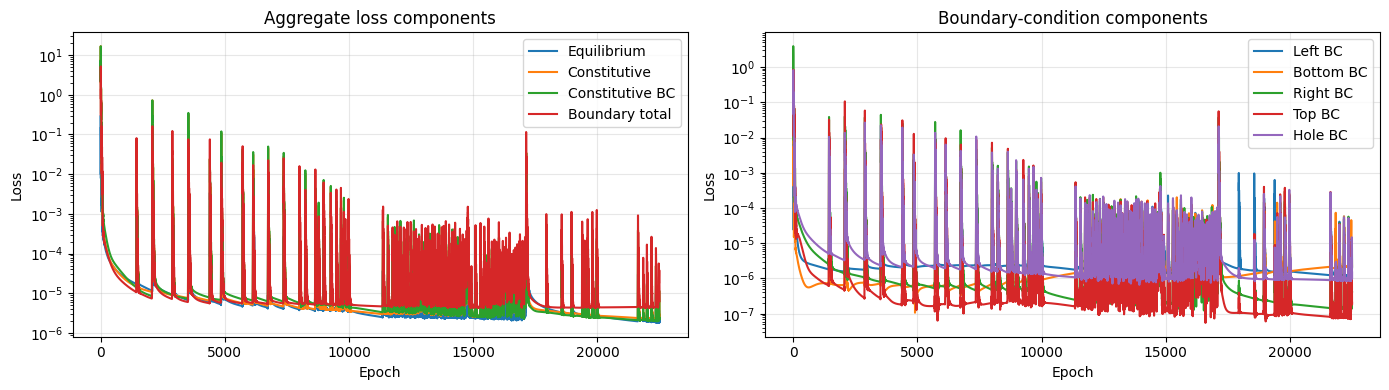

In [9]:
if not loss_history['total']:
    raise RuntimeError('Run the training cell before plotting losses.')

epochs = np.arange(1, len(loss_history['total']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

aggregate_terms = {
    'Equilibrium': loss_history['eq_total'],
    'Constitutive': loss_history['cons'],
    'Constitutive BC': loss_history['cons_bc'],
    'Boundary total': loss_history['bc_total'],
}

if any(value > 0 for value in loss_history['data']):
    aggregate_terms['Data'] = loss_history['data']

for label, values in aggregate_terms.items():
    axes[0].semilogy(epochs, np.maximum(np.asarray(values), 1e-16), label=label)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Aggregate loss components')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

boundary_terms = {
    'Left BC': loss_history['bc_L'],
    'Bottom BC': loss_history['bc_B'],
    'Right BC': loss_history['bc_R'],
    'Top BC': loss_history['bc_T'],
    'Hole BC': loss_history['bc_C'],
}

for label, values in boundary_terms.items():
    axes[1].semilogy(epochs, np.maximum(np.asarray(values), 1e-16), label=label)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Boundary-condition components')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
save_current_figure('loss_components.png')
plt.show()

## Plot the stress

In [10]:

# Load the best saved model before generating final field plots.
best_checkpoint = load_model_weights_from_checkpoint(BEST_CHECKPOINT_PATH)
print(f"Loaded best checkpoint from epoch {best_checkpoint['epoch']} with loss {best_checkpoint['current_loss']}")

# Plot the stress
import matplotlib.tri as mtri

stiff = E / (1 - mu ** 2) * torch.tensor([[1, mu, 0], [mu, 1, 0], [0, 0, (1 - mu) / 2]], dtype=FLOAT_BITS, device=device)
stiff = stiff.unsqueeze(0)

stiff_bc = stiff
stiff_full = stiff
stiff = torch.broadcast_to(stiff, (len(x), 3, 3))

stiff_bc = torch.broadcast_to(stiff_bc, (len(Boundary), 3, 3))
stiff_full = torch.broadcast_to(stiff_full, (len(x_full), 3, 3))

u_full = disp_net(x_full)
stress_full = stress_net(x_full)

xx = x_full[:,0].detach().cpu().numpy()
yy = x_full[:,1].detach().cpu().numpy()
sig11 = stress_full[:,1].detach().cpu().numpy()

connect =(t_connect -1).detach().cpu().numpy()

triang = mtri.Triangulation(xx, yy, connect)

u_11 = u_full[:,0].detach().cpu().numpy()

u = u_full[:, 0]
v = u_full[:, 1]

dudx = torch.autograd.grad(u, x_full, grad_outputs=torch.ones_like(u), create_graph=True)[0]
dvdx = torch.autograd.grad(v, x_full, grad_outputs=torch.ones_like(v), create_graph=True)[0]

e_11 = dudx[:, 0].unsqueeze(1)
e_22 = dvdx[:, 1].unsqueeze(1)
e_12 = 0.5 * (dudx[:, 1] + dvdx[:, 0]).unsqueeze(1)

e = torch.cat((e_11, e_22, e_12), 1)
e = e.unsqueeze(2)

sigma = torch.bmm(stiff_full, e).squeeze(2)

Loaded best checkpoint from epoch 22436 with loss 1.071151675281138e-05


Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/stress_sigma11.png


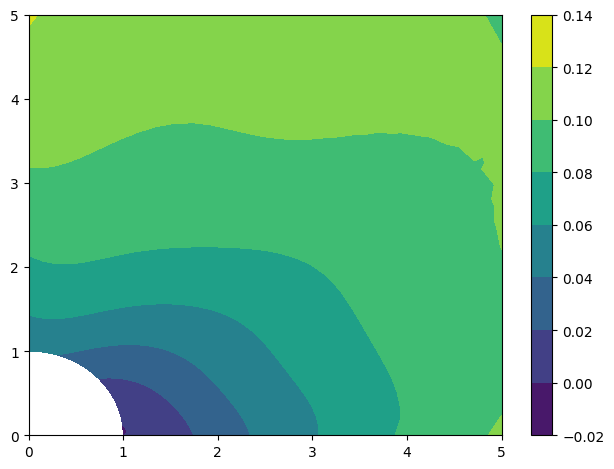

In [11]:
plt.figure(2)
plt.clf()
plt.tricontourf(triang,sigma[:,0].detach().cpu().numpy())
plt.colorbar()
plt.tight_layout()
save_current_figure('stress_sigma11.png')
plt.show()

## FEM comparison

In [12]:
disp_pred_full = disp_net(x_full)
disp_true_full = disp_truth
disp_error_full = disp_pred_full - disp_true_full

u_pred_np = disp_pred_full[:, 0].detach().cpu().numpy()
v_pred_np = disp_pred_full[:, 1].detach().cpu().numpy()
u_true_np = disp_true_full[:, 0].detach().cpu().numpy()
v_true_np = disp_true_full[:, 1].detach().cpu().numpy()
u_abs_err_np = np.abs(u_pred_np - u_true_np)
v_abs_err_np = np.abs(v_pred_np - v_true_np)

u_true_norm = torch.linalg.norm(disp_true_full[:, 0]).detach().cpu().item()
v_true_norm = torch.linalg.norm(disp_true_full[:, 1]).detach().cpu().item()
disp_true_norm = torch.linalg.norm(disp_true_full).detach().cpu().item()

fem_metrics = {
    'u_rmse': float(torch.sqrt(torch.mean((disp_error_full[:, 0]) ** 2)).detach().cpu().item()),
    'v_rmse': float(torch.sqrt(torch.mean((disp_error_full[:, 1]) ** 2)).detach().cpu().item()),
    'disp_rmse': float(torch.sqrt(torch.mean(disp_error_full ** 2)).detach().cpu().item()),
    'u_rel_l2': float(torch.linalg.norm(disp_error_full[:, 0]).detach().cpu().item() / max(u_true_norm, 1e-16)),
    'v_rel_l2': float(torch.linalg.norm(disp_error_full[:, 1]).detach().cpu().item() / max(v_true_norm, 1e-16)),
    'disp_rel_l2': float(torch.linalg.norm(disp_error_full).detach().cpu().item() / max(disp_true_norm, 1e-16)),
    'u_max_abs': float(np.max(u_abs_err_np)),
    'v_max_abs': float(np.max(v_abs_err_np)),
}

for name, value in fem_metrics.items():
    print(f'{name}: {value:.6e}')

fem_metrics_path = TRACKING_DIR / 'fem_comparison_metrics.json'
with fem_metrics_path.open('w', encoding='utf-8') as f:
    json.dump(fem_metrics, f, indent=2)
print(f'Saved FEM comparison metrics to {fem_metrics_path}')

u_rmse: 1.925921e-02
v_rmse: 1.515488e-02
disp_rmse: 1.732899e-02
u_rel_l2: 7.140435e-01
v_rel_l2: 1.576026e+00
disp_rel_l2: 8.558406e-01
u_max_abs: 4.087632e-02
v_max_abs: 2.884166e-02
Saved FEM comparison metrics to problem_1_experiments/problem1_20260313_233004_full_nodata_seed1234/tracking/fem_comparison_metrics.json


Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/fem_vs_pinn_displacement.png


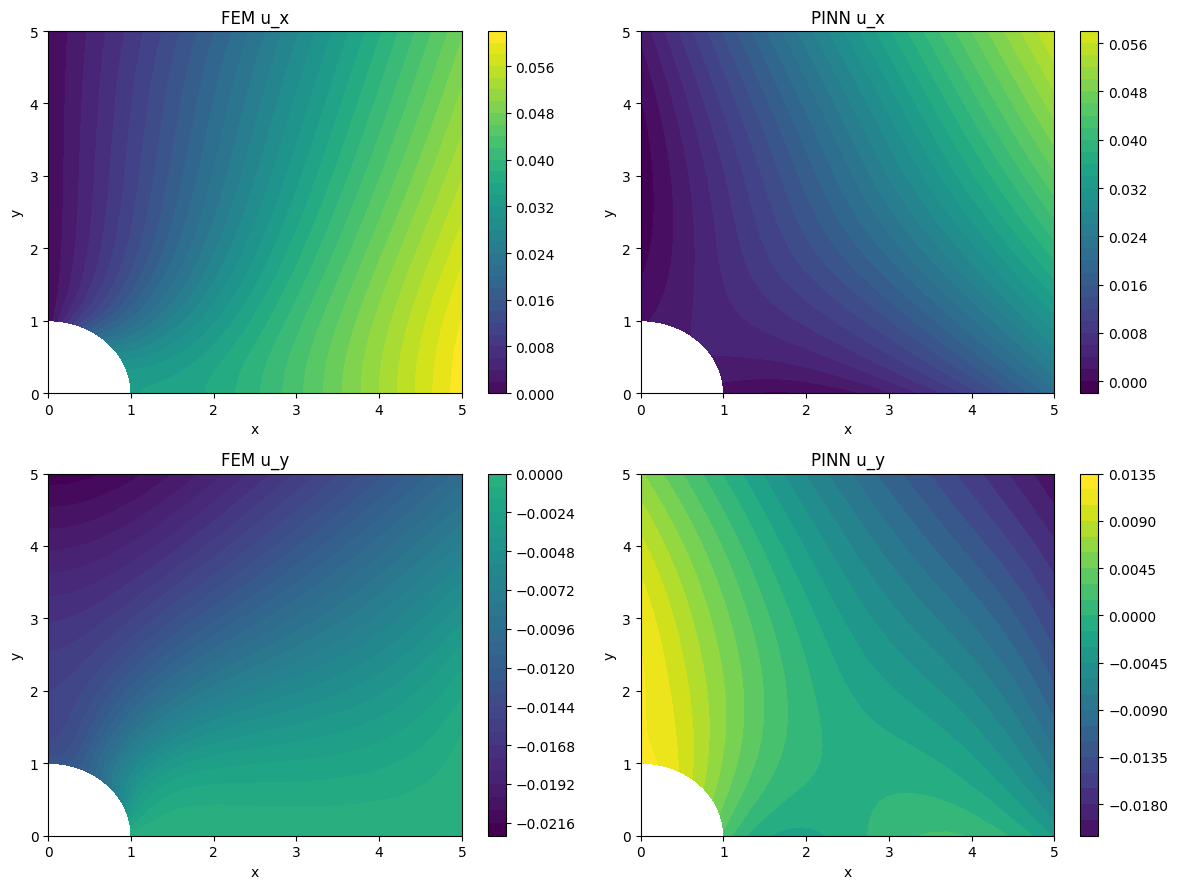

In [13]:
import matplotlib.tri as mtri

triang_fem = mtri.Triangulation(
    x_full[:, 0].detach().cpu().numpy(),
    x_full[:, 1].detach().cpu().numpy(),
    (t_connect - 1).detach().cpu().numpy(),
)

u_min, u_max = min(u_true_np.min(), u_pred_np.min()), max(u_true_np.max(), u_pred_np.max())
v_min, v_max = min(v_true_np.min(), v_pred_np.min()), max(v_true_np.max(), v_pred_np.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
u_truth_plot = axes[0, 0].tricontourf(triang_fem, u_true_np, levels=30, vmin=u_min, vmax=u_max)
axes[0, 0].set_title('FEM u_x')
fig.colorbar(u_truth_plot, ax=axes[0, 0])

u_pred_plot = axes[0, 1].tricontourf(triang_fem, u_pred_np, levels=30, vmin=u_min, vmax=u_max)
axes[0, 1].set_title('PINN u_x')
fig.colorbar(u_pred_plot, ax=axes[0, 1])

v_truth_plot = axes[1, 0].tricontourf(triang_fem, v_true_np, levels=30, vmin=v_min, vmax=v_max)
axes[1, 0].set_title('FEM u_y')
fig.colorbar(v_truth_plot, ax=axes[1, 0])

v_pred_plot = axes[1, 1].tricontourf(triang_fem, v_pred_np, levels=30, vmin=v_min, vmax=v_max)
axes[1, 1].set_title('PINN u_y')
fig.colorbar(v_pred_plot, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
save_current_figure('fem_vs_pinn_displacement.png')
plt.show()

Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/fem_displacement_error.png


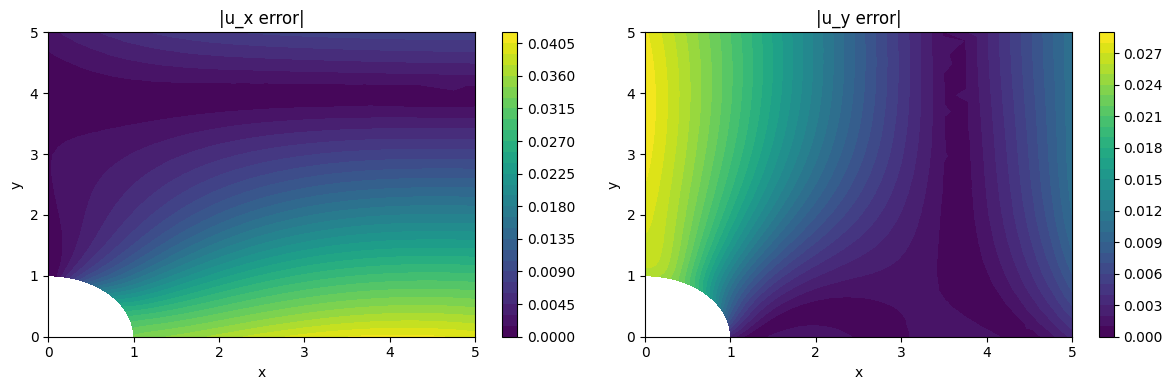

In [14]:
import matplotlib.tri as mtri

triang_fem = mtri.Triangulation(
    x_full[:, 0].detach().cpu().numpy(),
    x_full[:, 1].detach().cpu().numpy(),
    (t_connect - 1).detach().cpu().numpy(),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
u_err_plot = axes[0].tricontourf(triang_fem, u_abs_err_np, levels=30)
axes[0].set_title('|u_x error|')
fig.colorbar(u_err_plot, ax=axes[0])

v_err_plot = axes[1].tricontourf(triang_fem, v_abs_err_np, levels=30)
axes[1].set_title('|u_y error|')
fig.colorbar(v_err_plot, ax=axes[1])

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
save_current_figure('fem_displacement_error.png')
plt.show()

## Residual diagnostics

In [15]:
disp_diag_full = disp_net(x_full)
sigma_net_full = stress_net(x_full)

u_diag = disp_diag_full[:, 0]
v_diag = disp_diag_full[:, 1]
dudx_diag = torch.autograd.grad(u_diag, x_full, grad_outputs=torch.ones_like(u_diag), create_graph=True)[0]
dvdx_diag = torch.autograd.grad(v_diag, x_full, grad_outputs=torch.ones_like(v_diag), create_graph=True)[0]

e11_diag = dudx_diag[:, 0].unsqueeze(1)
e22_diag = dvdx_diag[:, 1].unsqueeze(1)
e12_diag = 0.5 * (dudx_diag[:, 1] + dvdx_diag[:, 0]).unsqueeze(1)
strain_diag = torch.cat((e11_diag, e22_diag, e12_diag), dim=1).unsqueeze(2)
sig_aug_full = torch.bmm(stiff_full, strain_diag).squeeze(2)

constitutive_residual_full = sigma_net_full - sig_aug_full
constitutive_residual_mag = torch.linalg.norm(constitutive_residual_full, dim=1)

sig11_full = sigma_net_full[:, 0]
sig22_full = sigma_net_full[:, 1]
sig12_full = sigma_net_full[:, 2]
dsig11_full = torch.autograd.grad(sig11_full, x_full, grad_outputs=torch.ones_like(sig11_full), create_graph=True)[0]
dsig22_full = torch.autograd.grad(sig22_full, x_full, grad_outputs=torch.ones_like(sig22_full), create_graph=True)[0]
dsig12_full = torch.autograd.grad(sig12_full, x_full, grad_outputs=torch.ones_like(sig12_full), create_graph=True)[0]

eq_residual_x = dsig11_full[:, 0] + dsig12_full[:, 1]
eq_residual_y = dsig12_full[:, 0] + dsig22_full[:, 1]
eq_residual_mag = torch.sqrt(eq_residual_x ** 2 + eq_residual_y ** 2)

eq_residual_x_np = eq_residual_x.detach().cpu().numpy()
eq_residual_y_np = eq_residual_y.detach().cpu().numpy()
eq_residual_mag_np = eq_residual_mag.detach().cpu().numpy()
constitutive_residual_np = constitutive_residual_full.detach().cpu().numpy()
constitutive_residual_mag_np = constitutive_residual_mag.detach().cpu().numpy()

def residual_summary(values):
    abs_values = np.abs(np.asarray(values))
    return {
        'mean_abs': float(np.mean(abs_values)),
        'median_abs': float(np.median(abs_values)),
        'p95_abs': float(np.percentile(abs_values, 95)),
        'max_abs': float(np.max(abs_values)),
    }

residual_metrics = {
    'equilibrium_x': residual_summary(eq_residual_x_np),
    'equilibrium_y': residual_summary(eq_residual_y_np),
    'equilibrium_magnitude': residual_summary(eq_residual_mag_np),
    'constitutive_sigma11': residual_summary(constitutive_residual_np[:, 0]),
    'constitutive_sigma22': residual_summary(constitutive_residual_np[:, 1]),
    'constitutive_sigma12': residual_summary(constitutive_residual_np[:, 2]),
    'constitutive_magnitude': residual_summary(constitutive_residual_mag_np),
}

for group, metrics in residual_metrics.items():
    print(group)
    for metric_name, metric_value in metrics.items():
        print(f'  {metric_name}: {metric_value:.6e}')

residual_metrics_path = TRACKING_DIR / 'residual_metrics.json'
with residual_metrics_path.open('w', encoding='utf-8') as f:
    json.dump(residual_metrics, f, indent=2)
print(f'Saved residual metrics to {residual_metrics_path}')

equilibrium_x
  mean_abs: 7.590438e-04
  median_abs: 4.332208e-04
  p95_abs: 2.360967e-03
  max_abs: 1.342940e-02
equilibrium_y
  mean_abs: 4.973357e-04
  median_abs: 2.938935e-04
  p95_abs: 1.991194e-03
  max_abs: 5.257564e-03
equilibrium_magnitude
  mean_abs: 1.052028e-03
  median_abs: 6.091843e-04
  p95_abs: 3.367357e-03
  max_abs: 1.343008e-02
constitutive_sigma11
  mean_abs: 9.184271e-04
  median_abs: 7.740272e-04
  p95_abs: 2.219798e-03
  max_abs: 3.211071e-03
constitutive_sigma22
  mean_abs: 7.525080e-04
  median_abs: 6.824572e-04
  p95_abs: 1.827686e-03
  max_abs: 2.671850e-03
constitutive_sigma12
  mean_abs: 1.698898e-03
  median_abs: 1.411161e-03
  p95_abs: 4.542100e-03
  max_abs: 9.213639e-03
constitutive_magnitude
  mean_abs: 2.311424e-03
  median_abs: 2.024926e-03
  p95_abs: 4.778290e-03
  max_abs: 9.402235e-03
Saved residual metrics to problem_1_experiments/problem1_20260313_233004_full_nodata_seed1234/tracking/residual_metrics.json


Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/residual_distributions.png


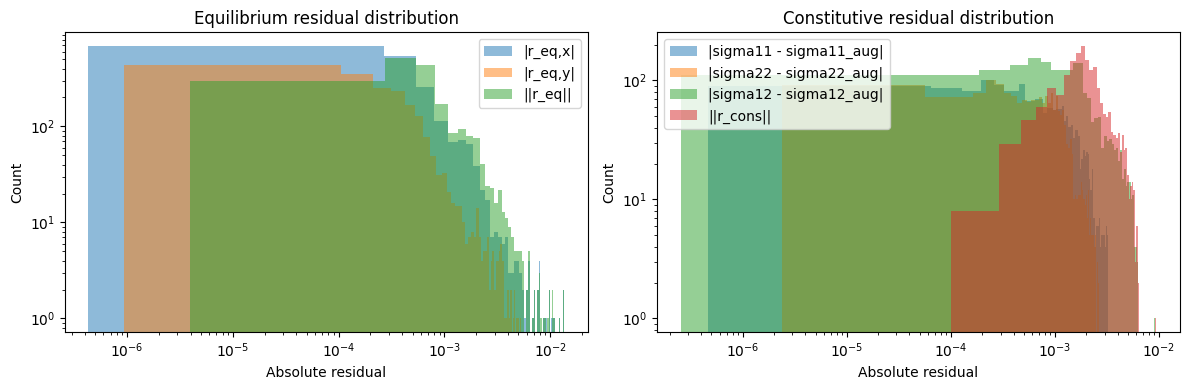

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eq_hist_terms = {
    '|r_eq,x|': np.maximum(np.abs(eq_residual_x_np), 1e-16),
    '|r_eq,y|': np.maximum(np.abs(eq_residual_y_np), 1e-16),
    '||r_eq||': np.maximum(eq_residual_mag_np, 1e-16),
}
for label, values in eq_hist_terms.items():
    axes[0].hist(values, bins=50, alpha=0.5, label=label)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Equilibrium residual distribution')
axes[0].set_xlabel('Absolute residual')
axes[0].set_ylabel('Count')
axes[0].legend()

cons_hist_terms = {
    '|sigma11 - sigma11_aug|': np.maximum(np.abs(constitutive_residual_np[:, 0]), 1e-16),
    '|sigma22 - sigma22_aug|': np.maximum(np.abs(constitutive_residual_np[:, 1]), 1e-16),
    '|sigma12 - sigma12_aug|': np.maximum(np.abs(constitutive_residual_np[:, 2]), 1e-16),
    '||r_cons||': np.maximum(constitutive_residual_mag_np, 1e-16),
}
for label, values in cons_hist_terms.items():
    axes[1].hist(values, bins=50, alpha=0.5, label=label)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Constitutive residual distribution')
axes[1].set_xlabel('Absolute residual')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
save_current_figure('residual_distributions.png')
plt.show()

Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/residual_spatial_maps.png


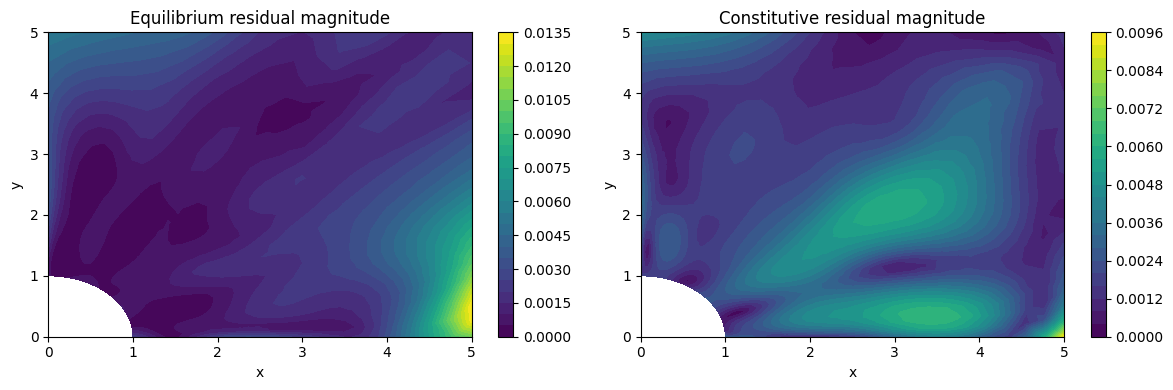

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eq_spatial = axes[0].tricontourf(triang_fem, np.maximum(eq_residual_mag_np, 1e-16), levels=30)
axes[0].set_title('Equilibrium residual magnitude')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(eq_spatial, ax=axes[0])

cons_spatial = axes[1].tricontourf(triang_fem, np.maximum(constitutive_residual_mag_np, 1e-16), levels=30)
axes[1].set_title('Constitutive residual magnitude')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(cons_spatial, ax=axes[1])

plt.tight_layout()
save_current_figure('residual_spatial_maps.png')
plt.show()

## FEM stress comparison

In [18]:
# Re-load the best checkpoint so the stress comparison uses the saved best model.
best_checkpoint = load_model_weights_from_checkpoint(BEST_CHECKPOINT_PATH)
print(
    f"Loaded best checkpoint from epoch {best_checkpoint['epoch']} "
    f"with loss {best_checkpoint['current_loss']} for FEM stress comparison"
)

import matplotlib.tri as mtri

def compute_cst_element_stress(coords_np, conn_np, nodal_disp_np, constitutive_np):
    """Reproduce the CST post-processing used in Plate_hole.m on each triangle."""
    elem_coords = coords_np[conn_np]
    n_elem = elem_coords.shape[0]

    me = np.concatenate(
        [
            np.ones((n_elem, 3, 1), dtype=coords_np.dtype),
            elem_coords,
        ],
        axis=2,
    )
    me_inv = np.linalg.inv(me)
    dndx = me_inv[:, 1, :]
    dndy = me_inv[:, 2, :]

    b_mats = np.zeros((n_elem, 3, 6), dtype=coords_np.dtype)
    b_mats[:, 0, 0::2] = dndx
    b_mats[:, 1, 1::2] = dndy
    b_mats[:, 2, 0::2] = dndy
    b_mats[:, 2, 1::2] = dndx

    elem_disp = nodal_disp_np[conn_np].reshape(n_elem, 6)
    elem_strain = np.einsum('eij,ej->ei', b_mats, elem_disp)
    elem_stress = elem_strain @ constitutive_np.T
    return elem_stress

def compute_pinn_constitutive_stress(points_np):
    query_points = torch.tensor(points_np, dtype=FLOAT_BITS, device=device, requires_grad=True)
    disp_query = disp_net(query_points)

    u_query = disp_query[:, 0]
    v_query = disp_query[:, 1]
    dudx_query = torch.autograd.grad(
        u_query,
        query_points,
        grad_outputs=torch.ones_like(u_query),
        create_graph=False,
        retain_graph=True,
    )[0]
    dvdx_query = torch.autograd.grad(v_query, query_points, grad_outputs=torch.ones_like(v_query), create_graph=False)[0]

    strain_query = torch.stack(
        [
            dudx_query[:, 0],
            dvdx_query[:, 1],
            0.5 * (dudx_query[:, 1] + dvdx_query[:, 0]),
        ],
        dim=1,
    )
    constitutive = E / (1 - mu ** 2) * torch.tensor(
        [[1, mu, 0], [mu, 1, 0], [0, 0, (1 - mu) / 2]],
        dtype=FLOAT_BITS,
        device=device,
    )
    stress_query = strain_query @ constitutive.T
    return stress_query.detach().cpu().numpy()

coords_full_np = x_full.detach().cpu().numpy()
conn_full_np = (t_connect - 1).detach().cpu().numpy().astype(np.int64)
disp_true_np = disp_truth.detach().cpu().numpy()

constitutive_np = (E / (1 - mu ** 2)) * np.array(
    [[1, mu, 0], [mu, 1, 0], [0, 0, (1 - mu) / 2]],
    dtype=coords_full_np.dtype,
)

fem_stress_elem_np = compute_cst_element_stress(coords_full_np, conn_full_np, disp_true_np, constitutive_np)
elem_centroids_np = coords_full_np[conn_full_np].mean(axis=1)
pinn_stress_elem_np = compute_pinn_constitutive_stress(elem_centroids_np)
stress_err_elem_np = pinn_stress_elem_np - fem_stress_elem_np
triang_stress_elem = mtri.Triangulation(coords_full_np[:, 0], coords_full_np[:, 1], conn_full_np)

stress_component_names = ['sigma11', 'sigma22', 'sigma12']
stress_component_titles = [r'$\sigma_{11}$', r'$\sigma_{22}$', r'$\sigma_{12}$']
fem_stress_metrics = {}
for idx, name in enumerate(stress_component_names):
    diff = stress_err_elem_np[:, idx]
    ref = fem_stress_elem_np[:, idx]
    fem_stress_metrics[name] = {
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'rel_l2': float(np.linalg.norm(diff) / max(np.linalg.norm(ref), 1e-16)),
        'max_abs': float(np.max(np.abs(diff))),
    }
    print(name)
    for metric_name, metric_value in fem_stress_metrics[name].items():
        print(f'  {metric_name}: {metric_value:.6e}')

fem_stress_metrics_path = TRACKING_DIR / 'fem_stress_comparison_metrics.json'
with fem_stress_metrics_path.open('w', encoding='utf-8') as f:
    json.dump(fem_stress_metrics, f, indent=2)
print(f'Saved FEM stress comparison metrics to {fem_stress_metrics_path}')

Loaded best checkpoint from epoch 22436 with loss 1.071151675281138e-05 for FEM stress comparison
sigma11
  rmse: 7.810594e-02
  rel_l2: 6.331102e-01
  max_abs: 2.940247e-01
sigma22
  rmse: 4.520305e-02
  rel_l2: 1.681408e+00
  max_abs: 1.809821e-01
sigma12
  rmse: 2.124731e-02
  rel_l2: 9.272886e-01
  max_abs: 7.604818e-02
Saved FEM stress comparison metrics to problem_1_experiments/problem1_20260313_233004_full_nodata_seed1234/tracking/fem_stress_comparison_metrics.json


Saved figure to problem_1_figures/problem1_20260313_233004_full_nodata_seed1234/fem_vs_pinn_stress_components.png


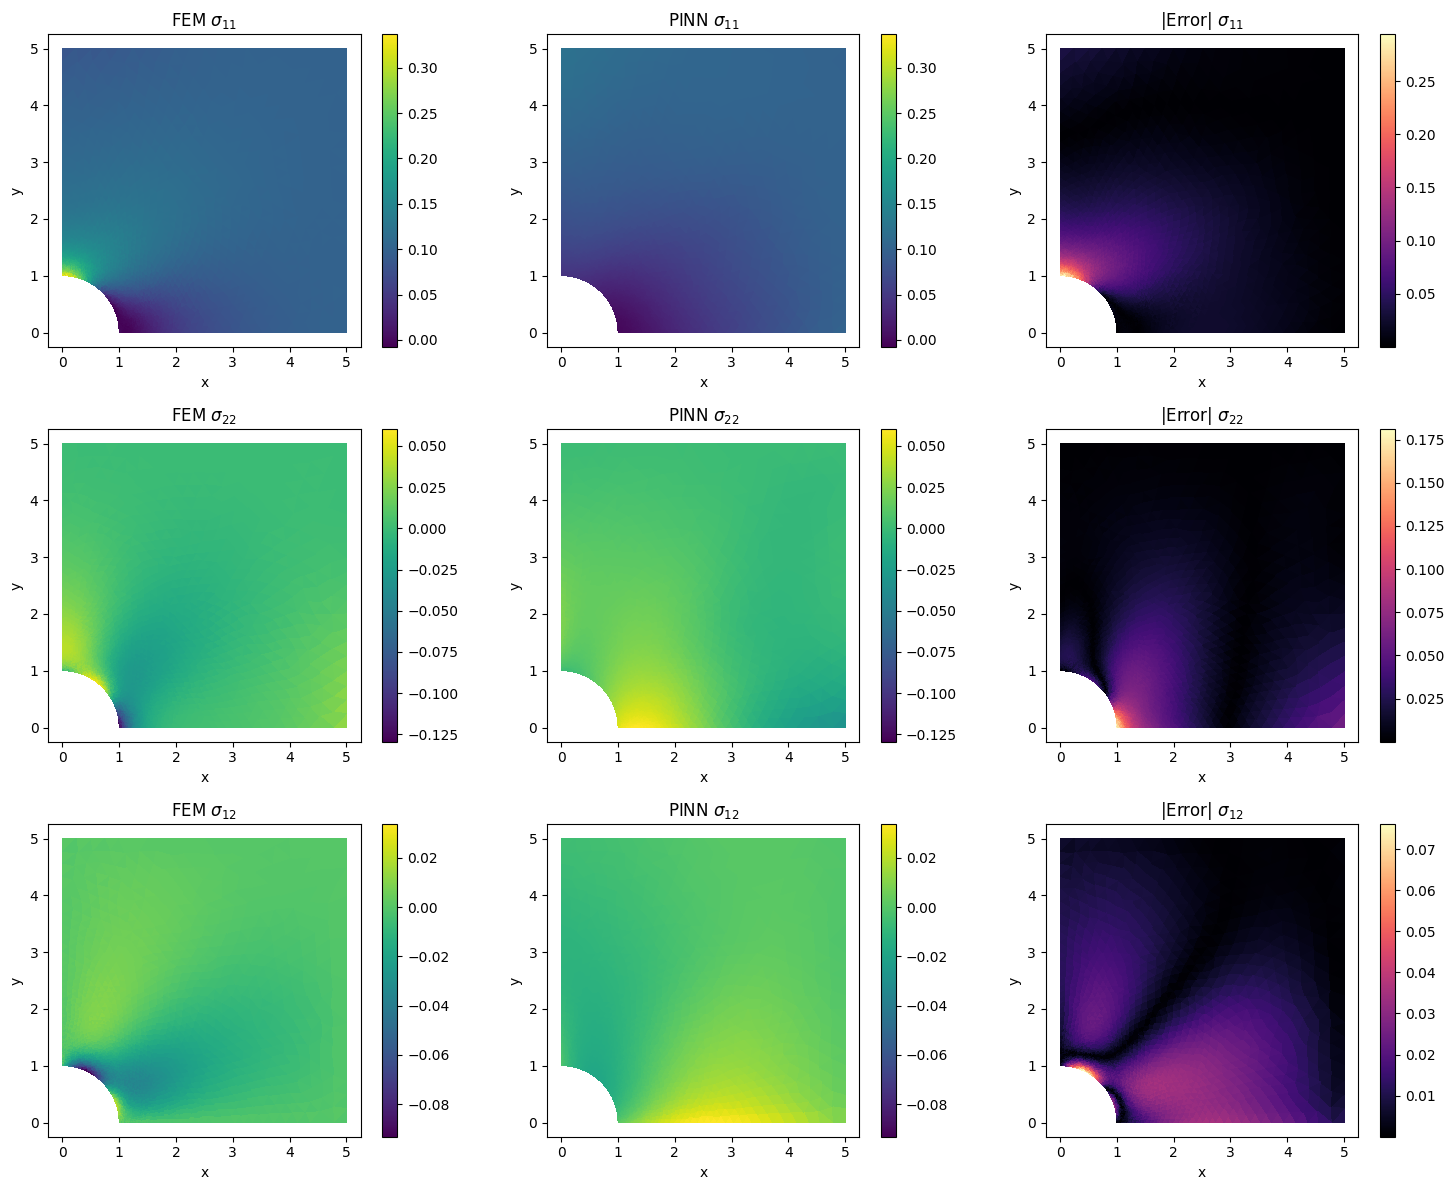

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, title in enumerate(stress_component_titles):
    fem_values = fem_stress_elem_np[:, idx]
    pinn_values = pinn_stress_elem_np[:, idx]
    error_values = np.abs(stress_err_elem_np[:, idx])
    vmin = min(fem_values.min(), pinn_values.min())
    vmax = max(fem_values.max(), pinn_values.max())

    fem_plot = axes[idx, 0].tripcolor(
        triang_stress_elem,
        facecolors=fem_values,
        shading='flat',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[idx, 0].set_title(f'FEM {title}')
    fig.colorbar(fem_plot, ax=axes[idx, 0])

    pinn_plot = axes[idx, 1].tripcolor(
        triang_stress_elem,
        facecolors=pinn_values,
        shading='flat',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[idx, 1].set_title(f'PINN {title}')
    fig.colorbar(pinn_plot, ax=axes[idx, 1])

    err_plot = axes[idx, 2].tripcolor(
        triang_stress_elem,
        facecolors=error_values,
        shading='flat',
        cmap='magma',
    )
    axes[idx, 2].set_title(f'|Error| {title}')
    fig.colorbar(err_plot, ax=axes[idx, 2])

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.tight_layout()
save_current_figure('fem_vs_pinn_stress_components.png')
plt.show()